In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data = pd.read_csv('/content/Dataset09-Employee-salary-prediction.csv')
data

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0
...,...,...,...,...,...,...
370,35.0,Female,Bachelor's,Senior Marketing Analyst,8.0,85000.0
371,43.0,Male,Master's,Director of Operations,19.0,170000.0
372,29.0,Female,Bachelor's,Junior Project Manager,2.0,40000.0
373,34.0,Male,Bachelor's,Senior Operations Coordinator,7.0,90000.0


In [ ]:
data.shape

(375, 6)

In [ ]:
data.columns

Index(['Age', 'Gender', 'Education Level', 'Job Title', 'Years of Experience',
       'Salary'],
      dtype='object')

In [ ]:
data.dtypes

,0
Age,float64
Gender,object
Education Level,object
Job Title,object
Years of Experience,float64
Salary,float64


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  373 non-null    float64
 1   Gender               373 non-null    object 
 2   Education Level      373 non-null    object 
 3   Job Title            373 non-null    object 
 4   Years of Experience  373 non-null    float64
 5   Salary               373 non-null    float64
dtypes: float64(3), object(3)
memory usage: 17.7+ KB


In [ ]:
data[data.duplicated()]

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
195,28.0,Male,Bachelor's,Junior Business Analyst,2.0,40000.0
250,30.0,Female,Bachelor's,Junior Marketing Coordinator,2.0,40000.0
251,38.0,Male,Master's,Senior IT Consultant,9.0,110000.0
252,45.0,Female,PhD,Senior Product Designer,15.0,150000.0
253,28.0,Male,Bachelor's,Junior Business Development Associate,2.0,40000.0
254,35.0,Female,Bachelor's,Senior Marketing Analyst,8.0,85000.0
255,44.0,Male,Bachelor's,Senior Software Engineer,14.0,130000.0
256,34.0,Female,Master's,Senior Financial Advisor,6.0,100000.0
257,35.0,Male,Bachelor's,Senior Project Coordinator,9.0,95000.0
258,50.0,Female,PhD,Director of Operations,22.0,180000.0


In [ ]:
data[data.duplicated()].shape

(50, 6)

In [ ]:
data1 = data.drop_duplicates(keep ='first')
data1.shape

(325, 6)

In [ ]:
data1.isnull().sum()

,0
Age,1
Gender,1
Education Level,1
Job Title,1
Years of Experience,1
Salary,1


In [ ]:
data1.dropna(how = 'any',inplace=True)
data1.shape

/tmp/ipython-input-11-3386200347.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data1.dropna(how = 'any',inplace=True)


(324, 6)

data visulazation and exploration

In [ ]:
data1.describe()

,Age,Years of Experience,Salary
count,324.000000,324.000000,324.000000
mean,37.382716,10.058642,99985.648148
std,7.185844,6.650470,48652.271440
min,23.000000,0.000000,350.000000
25%,31.000000,4.000000,55000.000000
50%,36.500000,9.000000,95000.000000
75%,44.000000,16.000000,140000.000000
max,53.000000,25.000000,250000.000000


In [ ]:
corr = data1[['Age','Years of Experience','Salary']].corr()
corr

,Age,Years of Experience,Salary
Age,1.000000,0.979192,0.916543
Years of Experience,0.979192,1.000000,0.924455
Salary,0.916543,0.924455,1.000000


<Axes: >

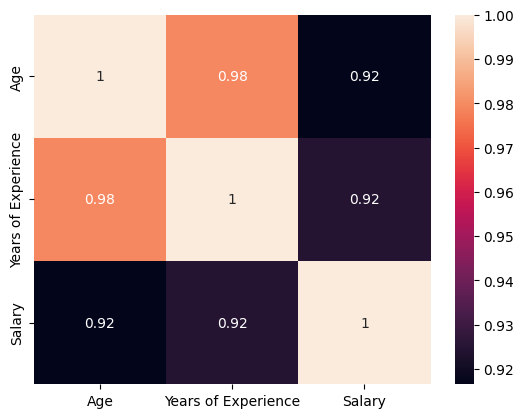

In [ ]:
sns.heatmap(corr, annot=True)

In [ ]:
data1['Education Level'].value_counts()

,count
Education Level,
Bachelor's,191
Master's,91
PhD,42


<Axes: xlabel='Education Level'>

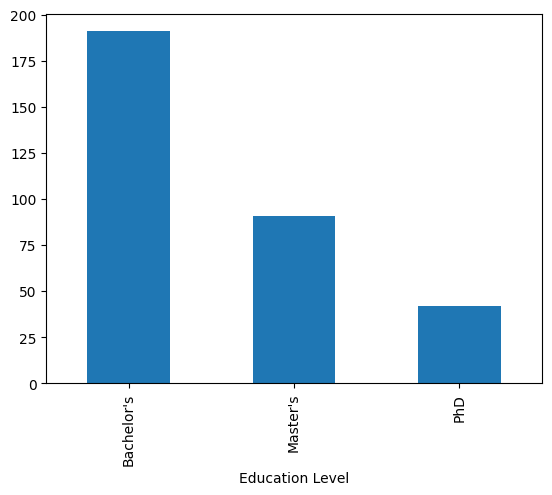

In [ ]:
data1['Education Level'].value_counts().plot(kind='bar')

In [ ]:
data1['Job Title'].value_counts()

,count
Job Title,
Director of Operations,9
Director of Marketing,8
Senior Marketing Manager,8
Senior Project Manager,7
Senior Data Scientist,6
...,...
Junior Social Media Specialist,1
Junior Operations Coordinator,1
Senior HR Specialist,1


In [ ]:
data1['Job Title'].unique()

array(['Software Engineer', 'Data Analyst', 'Senior Manager',
       'Sales Associate', 'Director', 'Marketing Analyst',
       'Product Manager', 'Sales Manager', 'Marketing Coordinator',
       'Senior Scientist', 'Software Developer', 'HR Manager',
       'Financial Analyst', 'Project Manager', 'Customer Service Rep',
       'Operations Manager', 'Marketing Manager', 'Senior Engineer',
       'Data Entry Clerk', 'Sales Director', 'Business Analyst',
       'VP of Operations', 'IT Support', 'Recruiter', 'Financial Manager',
       'Social Media Specialist', 'Software Manager', 'Junior Developer',
       'Senior Consultant', 'Product Designer', 'CEO', 'Accountant',
       'Data Scientist', 'Marketing Specialist', 'Technical Writer',
       'HR Generalist', 'Project Engineer', 'Customer Success Rep',
       'Sales Executive', 'UX Designer', 'Operations Director',
       'Network Engineer', 'Administrative Assistant',
       'Strategy Consultant', 'Copywriter', 'Account Manager',
      

In [ ]:
data1['Gender'].value_counts()

,count
Gender,
Male,170
Female,154


<Axes: xlabel='Gender'>

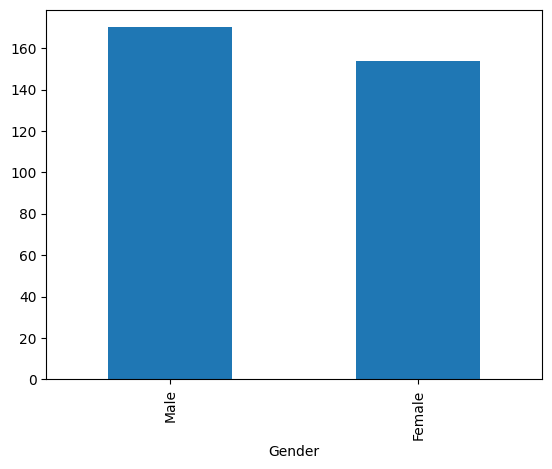

In [ ]:
data1['Gender'].value_counts().plot(kind='bar')

<Axes: ylabel='Frequency'>

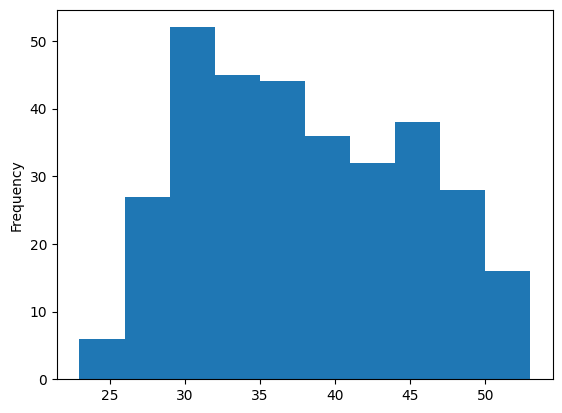

In [ ]:
data1.Age.plot(kind='hist')

<Axes: ylabel='Frequency'>

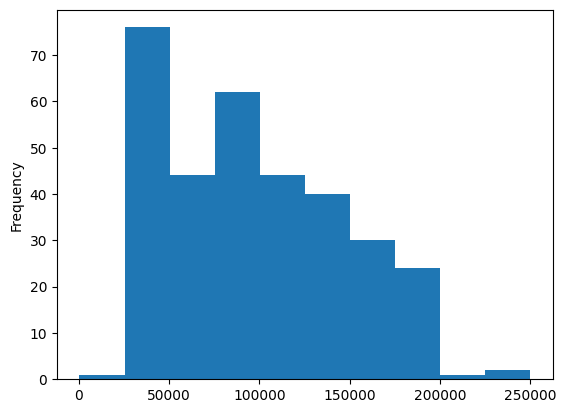

In [ ]:
 data1.Salary.plot(kind='hist')

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
data1['Education Level'] = le.fit_transform(data1['Education Level'])

/tmp/ipython-input-23-270377940.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data1['Education Level'] = le.fit_transform(data1['Education Level'])


In [ ]:
data1['Gender'] = le.fit_transform(data1['Gender'])

/tmp/ipython-input-24-1888859886.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data1['Gender'] = le.fit_transform(data1['Gender'])


In [ ]:
data1['Years of Experience'] = le.fit_transform(data1['Years of Experience'])

/tmp/ipython-input-25-3271148210.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data1['Years of Experience'] = le.fit_transform(data1['Years of Experience'])


In [ ]:
data1['Job Title'] = le.fit_transform(data1['Job Title'])

/tmp/ipython-input-26-540115615.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data1['Job Title'] = le.fit_transform(data1['Job Title'])


In [ ]:
data1

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,1,0,159,7,90000.0
1,28.0,0,1,17,5,65000.0
2,45.0,1,2,130,17,150000.0
3,36.0,0,0,101,9,60000.0
4,52.0,1,1,22,22,200000.0
...,...,...,...,...,...,...
348,28.0,0,0,68,2,35000.0
349,36.0,1,0,111,10,110000.0
350,44.0,0,2,115,18,160000.0
351,31.0,1,0,63,5,55000.0


In [ ]:
data1.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,1,0,159,7,90000.0
1,28.0,0,1,17,5,65000.0
2,45.0,1,2,130,17,150000.0
3,36.0,0,0,101,9,60000.0
4,52.0,1,1,22,22,200000.0


In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

In [ ]:
data1['Age'] = sc.fit_transform(data1[['Age']])
data1['Years of Experience'] = sc.fit_transform(data1[['Years of Experience']])

/tmp/ipython-input-30-2177978242.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data1['Age'] = sc.fit_transform(data1[['Age']])
/tmp/ipython-input-30-2177978242.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data1['Years of Experience'] = sc.fit_transform(data1[['Years of Experience']])


In [ ]:
data1.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,-0.750231,1,0,159,-0.742380,90000.0
1,-1.307742,0,1,17,-1.039515,65000.0
2,1.061680,1,2,130,0.743297,150000.0
3,-0.192720,0,0,101,-0.445244,60000.0
4,2.037324,1,1,22,1.486135,200000.0


In [ ]:
x = data1.drop(columns = 'Salary', axis = 1)
y = data1['Salary']
x.head()

,Age,Gender,Education Level,Job Title,Years of Experience
0,-0.750231,1,0,159,-0.742380
1,-1.307742,0,1,17,-1.039515
2,1.061680,1,2,130,0.743297
3,-0.192720,0,0,101,-0.445244
4,2.037324,1,1,22,1.486135


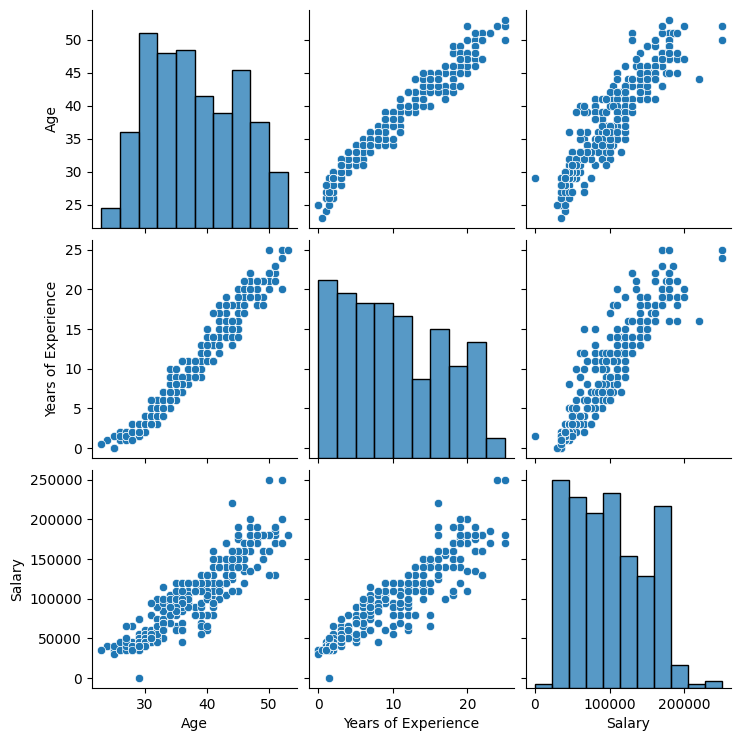

In [ ]:
sns.pairplot(data)
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 2)

In [ ]:
x_train.shape , y_train.shape

((259, 5), (259,))

In [ ]:
x_test.shape , y_test.shape

((65, 5), (65,))

In [ ]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x_train, y_train)

LinearRegression()

In [ ]:
y_pred = lr.predict(x_test)
y_pred

array([ 46491.18666461, 161967.71538752, 141845.89858615,  63528.51921348,
        61352.6400353 , 145760.86696153,  86191.41408686,  82526.90072297,
       144549.78720776, 102930.4855269 ,  39672.36053295, 154208.20969834,
        81441.50843039,  53328.56554521,  85634.09481604,  94790.20064916,
       162329.46220288, 162023.37363437, 164031.54126968,  55517.166077  ,
        52228.80228513, 164579.58416603, 150933.3040624 , 123107.93588529,
        73644.24870916, 118733.2916791 ,  74855.32846293,  95407.33525846,
       140292.97831327, 168437.51605742, 153497.3738429 ,  84581.45023066,
        88092.64770901,  49316.41205604,  86937.93831457,  85235.17892445,
       108765.24737271, 137922.32706028,  95750.56111404,  58954.86467204,
        56681.8639584 ,  44153.19485065, 116381.87349839,  40248.23255272,
        68875.75851457,  60188.67895621,  55522.26067002, 169555.80027728,
        39807.09188038,  65601.62147011,  77206.72195382,  42710.94253731,
       162032.65000885,  

In [ ]:
data2 = pd.DataFrame({'y_actual':y_test, 'y_pred':y_pred})
data2['Error'] = data2['y_actual'] - data2['y_pred']
data2['abs_error'] = abs(data2['Error'])
mean_abs_error = data2['abs_error'].mean()
mean_abs_error

np.float64(11949.792671985873)

In [ ]:
from sklearn.metrics import accuracy_score, r2_score, mean_squared_error, mean_absolute_error

In [ ]:
r2_score(y_test, y_pred)

0.8715759535890655

In [ ]:
round(mean_absolute_error(y_test, y_pred),2)

11949.79

In [ ]:
mse=round(mean_squared_error(y_test, y_pred),2)
mse

298813119.68

In [ ]:
print(('root mean squared error'),mse ** (0.5))

root mean squared error 17286.211837183993


In [ ]:
lr.coef_

array([2.45615074e+04, 9.72193999e+03, 1.59141226e+04, 9.27637448e+00,
       1.37666096e+04])

In [ ]:
lr.intercept_

np.float64(84781.41152207773)

In [ ]:
data1.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,-0.750231,1,0,159,-0.742380,90000.0
1,-1.307742,0,1,17,-1.039515,65000.0
2,1.061680,1,2,130,0.743297,150000.0
3,-0.192720,0,0,101,-0.445244,60000.0
4,2.037324,1,1,22,1.486135,200000.0


In [ ]:
Age1 = sc.transform([[36]])
Age =  -0.192720
Gender = 0
Education_Level = 0
Job_Title=101
Years_of_Experience1 = sc.transform([[9]])
Years_of_Experience = -0.445244

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
sc.transform([[18]])

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[0.89186457]])

In [ ]:
employe_salary = lr.predict([[Age,Gender,Education_Level,Job_Title,Years_of_Experience]])
employe_salary

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([74855.33129344])

Random Forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor
rf_regressor = RandomForestRegressor(random_state=2)
rf_regressor.fit(x_train, y_train)

RandomForestRegressor(random_state=2)

In [ ]:
y_pred_rf = rf_regressor.predict(x_test)

In [ ]:
r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)

print(f"R-squared: {r2_rf}")
print(f"Mean Absolute Error: {mae_rf}")
print(f"Mean Squared Error: {mse_rf}")

R-squared: 0.8897837234613271
Mean Absolute Error: 10998.779853479853
Mean Squared Error: 256447840.98013693


Voting Regressor

In [ ]:
from sklearn.ensemble import VotingRegressor

In [ ]:
estimators = [('lr', lr), ('rf', rf_regressor)]

In [ ]:
voting_regressor = VotingRegressor(estimators=estimators)
voting_regressor.fit(x_train, y_train)

VotingRegressor(estimators=[('lr', LinearRegression()),
                            ('rf', RandomForestRegressor(random_state=2))])

In [ ]:
y_pred_voting = voting_regressor.predict(x_test)

In [ ]:
r2_voting = r2_score(y_test, y_pred_voting)
mae_voting = mean_absolute_error(y_test, y_pred_voting)
mse_voting = mean_squared_error(y_test, y_pred_voting)

print(f"Voting Regressor R-squared: {r2_voting}")
print(f"Voting Regressor Mean Absolute Error: {mae_voting}")
print(f"Voting Regressor Mean Squared Error: {mse_voting}")

Voting Regressor R-squared: 0.8961877584693398
Voting Regressor Mean Absolute Error: 10626.978483063123
Voting Regressor Mean Squared Error: 241547129.3707236


In [ ]:
print(f"Voting Regressor R-squared: {r2_voting}")
print(f"Voting Regressor Mean Absolute Error: {mae_voting}")
print(f"Voting Regressor Mean Squared Error: {mse_voting}")

Voting Regressor R-squared: 0.8961877584693398
Voting Regressor Mean Absolute Error: 10626.978483063123
Voting Regressor Mean Squared Error: 241547129.3707236


### Gradient Boosting Regressor

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(random_state=2)
gbr.fit(x_train, y_train)

GradientBoostingRegressor(random_state=2)

In [ ]:
y_pred_gbr = gbr.predict(x_test)

In [ ]:
r2_gbr = r2_score(y_test, y_pred_gbr)
mae_gbr = mean_absolute_error(y_test, y_pred_gbr)
mse_gbr = mean_squared_error(y_test, y_pred_gbr)

print(f"Gradient Boosting Regressor R-squared: {r2_gbr}")
print(f"Gradient Boosting Regressor Mean Absolute Error: {mae_gbr}")
print(f"Gradient Boosting Regressor Mean Squared Error: {mse_gbr}")

Gradient Boosting Regressor R-squared: 0.894082909803769
Gradient Boosting Regressor Mean Absolute Error: 10747.498312525438
Gradient Boosting Regressor Mean Squared Error: 246444626.48119956


In [ ]:
import joblib

# Save the trained Voting Regressor model
joblib.dump(voting_regressor, "voting_regressor_model.pkl")
print("Voting Regressor model saved as voting_regressor_model.pkl")

Voting Regressor model saved as voting_regressor_model.pkl


In [ ]:
   import joblib
   from sklearn.preprocessing import LabelEncoder, StandardScaler

   # Create LabelEncoders
   le_gender = LabelEncoder()
   le_gender.fit(data['Gender'])
   joblib.dump(le_gender, 'label_encoder_gender.pkl')

   le_education = LabelEncoder()
   le_education.fit(data['Education Level'])
   joblib.dump(le_education, 'label_encoder_education.pkl')

   le_job_title = LabelEncoder()
   le_job_title.fit(data['Job Title'])
   joblib.dump(le_job_title, 'label_encoder_jobtitle.pkl')

   # Create and fit StandardScaler
   scaler = StandardScaler()
   scaler.fit(data[['Age', 'Years of Experience']])
   joblib.dump(scaler, 'standard_scaler.pkl')


['standard_scaler.pkl']

In [ ]:
! pip install streamlit -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 62.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 101.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 6.6 MB/s eta 0:00:00


In [69]:
# !wget -q -O - ipv4.icanhazip.com
# uncomment for ipv4 id

In [68]:
! streamlit run app.py & npx localtunnel --port 8501
# past the ipv4 id in the below URL for the output.



⠙⠹⠸⠼⠴⠦
  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.106.204.39:8501

⠧⠇⠏⠋Need to install the following packages:
localtunnel@2.0.2
Ok to proceed? (y) y

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹your url is: https://purple-houses-start.loca.lt
  Stopping...
^C


In [ ]:
y

## Model Summary

**Objective:** The goal is to predict employee salaries based on features like Age, Gender, Education Level, Job Title, and Years of Experience.

**Algorithms Used:**

1.  **Linear Regression:** A basic regression model used as a baseline.
2.  **Random Forest Regressor:** An ensemble learning method that builds multiple decision trees and merges their predictions to improve accuracy and control overfitting.
3.  **Voting Regressor:** An ensemble meta-estimator that aggregates the predictions of multiple base regressors (in this case, Linear Regression and Random Forest) to produce a final prediction. This often leads to improved performance compared to individual models.
4.  **Gradient Boosting Regressor:** Another ensemble method that builds trees sequentially, where each new tree corrects the errors of the previous ones.

**Important Points and Key Findings:**

*   **Data Cleaning:** You handled missing values by dropping rows with any missing data (`data1.dropna`). You also removed duplicate rows (`data.drop_duplicates`).
*   **Data Transformation:**
    *   Categorical features ('Gender', 'Education Level', 'Job Title') were converted into numerical representations using `LabelEncoder`.
    *   Numerical features ('Age', 'Years of Experience') were scaled using `StandardScaler`.
*   **Feature Correlation:** You visualized the correlation between numerical features ('Age', 'Years of Experience', 'Salary') using a heatmap, showing a strong positive correlation between these features.
*   **Model Evaluation:** You evaluated the models using the following metrics:
    *   **R-squared:** Measures the proportion of the variance in the dependent variable (Salary) that is predictable from the independent variables. Higher R-squared indicates a better fit.
    *   **Mean Absolute Error (MAE):** Measures the average magnitude of the errors in a set of predictions, without considering their direction. Lower MAE indicates better accuracy.
    *   **Mean Squared Error (MSE):** Measures the average of the squares of the errors. It gives more weight to larger errors. Lower MSE indicates better accuracy.
*   **Model Performance Comparison:** Based on the evaluation metrics (R-squared, MAE, MSE), the **Voting Regressor** appears to be the best-performing model among the ones you trained.

**Step-by-Step Flow of the Model:**

1.  **Load Data:** The dataset is loaded into a pandas DataFrame.
2.  **Explore Data:** Initial exploration includes checking the shape, columns, data types, and looking for duplicate and missing values.
3.  **Clean Data:** Duplicate rows are removed, and rows with missing values are dropped.
4.  **Visualize Data:** Basic visualizations like bar plots for categorical features and histograms for numerical features are created. A heatmap shows the correlation between numerical features.
5.  **Transform Data:**
    *   Categorical features are encoded using `LabelEncoder`.
    *   Numerical features are scaled using `StandardScaler`.
6.  **Split Data:** The data is split into training and testing sets.
7.  **Train Models:**
    *   A Linear Regression model is trained on the training data.
    *   A Random Forest Regressor model is trained on the training data.
    *   A Voting Regressor model is trained using the trained Linear Regression and Random Forest models.
    *   A Gradient Boosting Regressor model is trained on the training data.
8.  **Predict Salaries:** The trained models are used to predict salaries on the test data.
9.  **Evaluate Models:** The performance of each model is evaluated using R-squared, MAE, and MSE.
10. **Save Artifacts:** The best-performing model (Voting Regressor) and the fitted LabelEncoders and StandardScaler are saved for later use (e.g., in a deployment application like Streamlit).
11. **Deployment (Streamlit):** Although not fully functional in the notebook environment, the code includes steps to build a Streamlit application (`app.py`) that loads the saved model and transformers to make predictions based on user input.

This flow represents a typical machine learning workflow for a regression problem, including data preparation, model training, evaluation, and deployment.